In [3]:
import snowflake.connector
from sqlalchemy import create_engine
from sqlalchemy import text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime
from scipy.stats import zscore
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from catboost import CatBoostClassifier
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LassoCV
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta

from snowflake.connector.pandas_tools import write_pandas

In [144]:
pd.set_option('display.max_columns', None)

In [6]:
url = URL(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
)
engine = create_engine(url)
connection = engine.connect()

In [119]:
holiday_function = '''
CREATE OR REPLACE FUNCTION is_holiday(dt DATE)
RETURNS BOOLEAN
LANGUAGE PYTHON
RUNTIME_VERSION = '3.10'
PACKAGES = ('holidays')
HANDLER = 'check_holiday'
AS
$$
import holidays

def check_holiday(dt):
    if dt is None:
        return False
    return dt in holidays.US()
$$;
'''

query = '''

with 
calls_logs as (
select 
*,
--call_date,
SPLIT_PART(customers_tb.vertical_type_bin, '_', 1) as vertical_type
from DBT_PROD.ANALYTICS.FCT_CSR_CALL_LOG 
left join DBT_PROD.ANALYTICS.FCT_CUSTOMER_SALES as customers_tb using(customer_id)
where call_start_at > '2023-01-01' and call_start_at < '2026-03-01' 
and call_type in ('Inbound')
--group by 1
),

date_spine as (
select 
calendar_date as date,
day_name,
day_of_month,
month_name,
IFF(DAYOFMONTH(calendar_date) IN (1, 3, 15) OR DAYNAME(calendar_date) IN ('Fri', 'Sat'), 1, 0) AS is_billing_day,
case when is_holiday(calendar_date) = true then 1 else 0 end AS is_holiday
from DBT_PROD.ANALYTICS.DIM_CALENDAR
),

calls_agg as (
select 
call_date as date,
count(*) as num_calls,
from calls_logs
group by 1
),

transactions_agg as (
select 
transaction_date as date,
count(case when cascade_type is null then transaction_id else null end) as num_core_txn,
count(case when cascade_type is not null then transaction_id else null end) as num_casc_txn
from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
where transaction_date > '2023-01-01' and transaction_date < '2026-03-01' and is_sale = 1 and invoice_type != 'trial_invoice'
group by 1
),


m0_agg as (
select 
order_date as date,
count(case when cascade_type is null and is_m0 = 1 then order_id else null end) as num_core_m0,
count(case when cascade_type is not null and is_m0 = 1  then order_id else null end) as num_casc_m0
from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
where order_date > '2023-01-01' and order_date < '2026-03-01' and is_sale = 1
group by 1
),

date_distance as (
select
date,
MAX(IFF(is_billing_day=1, date, NULL)) OVER (ORDER BY date ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS last_billing_date,
MIN(IFF(is_billing_day=1, date, NULL)) OVER (ORDER BY date ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING) AS next_billing_date,
MAX(IFF(is_holiday=1, date, NULL)) OVER (ORDER BY date ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS last_holiday_date,
MIN(IFF(is_holiday=1, date, NULL)) OVER (ORDER BY date ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING) AS next_holiday_date
from date_spine
),

final as (
select 
date_spine.*,
calls_agg.num_calls,
transactions_agg.num_core_txn,
transactions_agg.num_casc_txn,
m0_agg.num_core_m0,
m0_agg.num_casc_m0,
-- days since/until
DATEDIFF('day', last_holiday_date, date) AS days_since_holiday,
DATEDIFF('day', date, next_holiday_date) AS days_until_holiday,

DATEDIFF('day', last_billing_date, date) AS days_since_billing_day,
DATEDIFF('day', date, next_billing_date) AS days_until_billing_day,
-- tnx and m0
AVG(num_core_txn) OVER (ORDER BY date ROWS BETWEEN 9 PRECEDING AND 7 PRECEDING) AS rolling_avg_core_txn_3d,
AVG(num_casc_txn) OVER (ORDER BY date ROWS BETWEEN 9 PRECEDING AND 7 PRECEDING) AS rolling_avg_casc_txn_3d,
AVG(num_core_m0) OVER (ORDER BY date ROWS BETWEEN 9 PRECEDING AND 7 PRECEDING) AS rolling_avg_core_m0_3d,
AVG(num_casc_m0) OVER (ORDER BY date ROWS BETWEEN 9 PRECEDING AND 7 PRECEDING) AS rolling_avg_casc_m0_3d,
-- calls
LAG(num_calls, 7) OVER (ORDER BY date) AS calls_7d_ago,
AVG(num_calls) OVER (ORDER BY date ROWS BETWEEN 9 PRECEDING AND 7 PRECEDING) AS rolling_avg_calls_3d,
AVG(num_calls) OVER (ORDER BY date ROWS BETWEEN 14 PRECEDING AND 7 PRECEDING) AS rolling_avg_calls_7d,
AVG(num_calls) OVER (ORDER BY date ROWS BETWEEN 36 PRECEDING AND 7 PRECEDING) AS rolling_avg_calls_30d,
from date_spine
left join calls_agg using(date)
left join transactions_agg using(date)
left join m0_agg using(date)
left join date_distance using(date)
)

select * from final
where date > '2023-01-01' and date < '2026-03-01'  
'''

In [121]:
with engine.connect() as con:
    con.execute(text("use database dbt_prod"))
    con.execute(text("use schema ANALYTICS"))
    con.execute(text(holiday_function))
    df_raw = pd.read_sql(query, con)

In [122]:
df_raw.dtypes

date                        object
day_name                    object
day_of_month                 int64
month_name                  object
is_billing_day               int64
is_holiday                   int64
num_calls                  float64
num_core_txn                 int64
num_casc_txn                 int64
num_core_m0                  int64
num_casc_m0                  int64
days_since_holiday           int64
days_until_holiday           int64
days_since_billing_day       int64
days_until_billing_day       int64
rolling_avg_core_txn_3d    float64
rolling_avg_casc_txn_3d    float64
rolling_avg_core_m0_3d     float64
rolling_avg_casc_m0_3d     float64
calls_7d_ago               float64
rolling_avg_calls_3d       float64
rolling_avg_calls_7d       float64
rolling_avg_calls_30d      float64
dtype: object

In [123]:
df_raw

,date,day_name,day_of_month,month_name,is_billing_day,is_holiday,num_calls,num_core_txn,num_casc_txn,num_core_m0,...,days_since_billing_day,days_until_billing_day,rolling_avg_core_txn_3d,rolling_avg_casc_txn_3d,rolling_avg_core_m0_3d,rolling_avg_casc_m0_3d,calls_7d_ago,rolling_avg_calls_3d,rolling_avg_calls_7d,rolling_avg_calls_30d
0,2023-01-02,Mon,2,Jan,0,1,2582.0,7783,570,9604,...,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-03,Tue,3,Jan,1,0,3421.0,8980,1157,8692,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-04,Wed,4,Jan,0,0,3052.0,7023,514,8433,...,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-01-05,Thu,5,Jan,0,0,2607.0,11012,627,9666,...,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-01-06,Fri,6,Jan,1,0,2594.0,8589,1952,8766,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,2026-02-24,Tue,24,Feb,0,0,2695.0,11602,2124,4611,...,3,3,13843.666,4899.666,5331.666,3595.666,2945.0,2523.666,2572.625,2717.766
1150,2026-02-25,Wed,25,Feb,0,0,2607.0,11092,1902,4730,...,4,2,11558.000,1901.000,5614.333,3946.666,2721.0,2894.000,2577.500,2712.800
1151,2026-02-26,Thu,26,Feb,0,0,2626.0,12825,3019,3845,...,5,1,12050.333,2343.333,5450.000,3918.666,2537.0,2734.333,2594.375,2701.366
1152,2026-02-27,Fri,27,Feb,1,0,4504.0,58115,51824,4283,...,0,0,23001.333,13284.333,5360.333,3799.000,3968.0,3075.333,2799.000,2745.200


In [124]:
df_raw.isnull().sum()

date                       0
day_name                   0
day_of_month               0
month_name                 0
is_billing_day             0
is_holiday                 0
num_calls                  1
num_core_txn               0
num_casc_txn               0
num_core_m0                0
num_casc_m0                0
days_since_holiday         0
days_until_holiday         0
days_since_billing_day     0
days_until_billing_day     0
rolling_avg_core_txn_3d    7
rolling_avg_casc_txn_3d    7
rolling_avg_core_m0_3d     7
rolling_avg_casc_m0_3d     7
calls_7d_ago               7
rolling_avg_calls_3d       6
rolling_avg_calls_7d       6
rolling_avg_calls_30d      6
dtype: int64

In [135]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Convert date to datetime and SORT (Crucial for time-series)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

# 2. Drop initial rows with NaNs caused by your 30-day rolling averages
df_clean = df_raw.dropna(subset=['num_calls', 'rolling_avg_calls_30d']).copy()

# 3. Define Features, Target, and Categorical Columns
target_col = 'num_calls'
# We drop 'date' so the model doesn't memorize timestamps
feature_cols = [col for col in df_clean.columns if col not in ['date', target_col]]

# CatBoost needs to know which columns are strings/categories
cat_features = ['day_name', 'month_name']

# 4. Chronological Train/Test Split
# Let's hold out the last 45 days of your dataset as the "Future" Test Set
test_days = 100
split_idx = len(df_clean) - test_days

train_df = df_clean.iloc[:split_idx]
test_df  = df_clean.iloc[split_idx:]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Training on {len(X_train)} days, Testing on {len(X_test)} days.")

# 5. Initialize the CatBoost Model
model = CatBoostRegressor(
    iterations=1500,           # Max number of trees
    learning_rate=0.03,        # Smaller learning rate = better generalization
    depth=6,                   # Tree depth (6 is usually the sweet spot for tabular)
    cat_features=cat_features, # Pass our string columns
    eval_metric='RMSE',        # Root Mean Squared Error
    random_seed=42,
    early_stopping_rounds=50,  # Stops training if test error doesn't improve for 50 rounds
    verbose=100                # Print progress every 100 trees
)

# 6. Fit the Model
print("Training CatBoost Model...")
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True        # Keeps the best tree based on the eval_set
)

# 7. Evaluate Performance
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\n--- Model Performance on Last 45 Days ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} calls")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} calls")

Training on 1047 days, Testing on 100 days.
Training CatBoost Model...
0:	learn: 822.5418274	test: 1542.4478462	best: 1542.4478462 (0)	total: 1.49ms	remaining: 2.24s
100:	learn: 215.8326295	test: 641.0573720	best: 641.0573720 (100)	total: 118ms	remaining: 1.64s
200:	learn: 160.4399726	test: 550.7834781	best: 550.7834781 (200)	total: 227ms	remaining: 1.46s
300:	learn: 136.0177801	test: 513.3618107	best: 513.3618107 (300)	total: 325ms	remaining: 1.3s
400:	learn: 121.0658258	test: 497.9786149	best: 497.9786149 (400)	total: 423ms	remaining: 1.16s
500:	learn: 109.5176838	test: 494.6119360	best: 494.0528659 (476)	total: 521ms	remaining: 1.04s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 494.0528659
bestIteration = 476

Shrink model to first 477 iterations.

--- Model Performance on Last 45 Days ---
Mean Absolute Error (MAE): 347.29 calls
Root Mean Squared Error (RMSE): 494.05 calls


In [137]:
import numpy as np

# 1. Create a results DataFrame
results_df = pd.DataFrame({
    'date': test_df['date'],
    'actual_calls': y_test.values,
    # Round predictions to whole numbers since you can't have a fraction of a call
    'predicted_calls': np.round(preds, 0), 
    'error': np.round(preds - y_test.values, 0)
})

# 2. Add an Absolute Error column to see the magnitude of the miss
results_df['abs_error'] = np.abs(results_df['error'])

# 3. Sort chronologically just to be safe
results_df = results_df.sort_values('date')

# 4. Print all 45 rows without pandas truncating the middle
print(results_df.to_string(index=False))

# --- OPTIONAL: Find your absolute worst predictions ---
print("\n--- Top 5 Worst Prediction Days ---")
print(results_df.sort_values('abs_error', ascending=False).head(5).to_string(index=False))

      date  actual_calls  predicted_calls   error  abs_error
2025-11-20        3403.0           3397.0    -6.0        6.0
2025-11-21        4941.0           4624.0  -317.0      317.0
2025-11-22        2568.0           2475.0   -93.0       93.0
2025-11-23        1594.0           1601.0     7.0        7.0
2025-11-24        3936.0           3888.0   -48.0       48.0
2025-11-25        3219.0           3335.0   116.0      116.0
2025-11-26        2748.0           2976.0   228.0      228.0
2025-11-27         874.0           2255.0  1381.0     1381.0
2025-11-28        4420.0           4166.0  -254.0      254.0
2025-11-29        2444.0           2488.0    44.0       44.0
2025-11-30        1724.0           1695.0   -29.0       29.0
2025-12-01        4846.0           4306.0  -540.0      540.0
2025-12-02        3799.0           3508.0  -291.0      291.0
2025-12-03        4684.0           3929.0  -755.0      755.0
2025-12-04        3439.0           2386.0 -1053.0     1053.0
2025-12-05        4597.0

In [146]:
df_raw[df_raw['date'] == '2025-11-27']

,date,day_name,day_of_month,month_name,is_billing_day,is_holiday,num_calls,num_core_txn,num_casc_txn,num_core_m0,num_casc_m0,days_since_holiday,days_until_holiday,days_since_billing_day,days_until_billing_day,rolling_avg_core_txn_3d,rolling_avg_casc_txn_3d,rolling_avg_core_m0_3d,rolling_avg_casc_m0_3d,calls_7d_ago,rolling_avg_calls_3d,rolling_avg_calls_7d,rolling_avg_calls_30d
1060,2025-11-27,Thu,27,Nov,0,1,874.0,11158,2090,7535,6165,0,0,5,1,12301.333,1896.666,13508.666,11458.0,3403.0,3420.666,3311.5,3418.033


In [139]:
results_df.mean()

date               2026-01-09 03:36:00
actual_calls                   3084.29
predicted_calls                2826.83
error                          -257.46
abs_error                        347.3
dtype: object

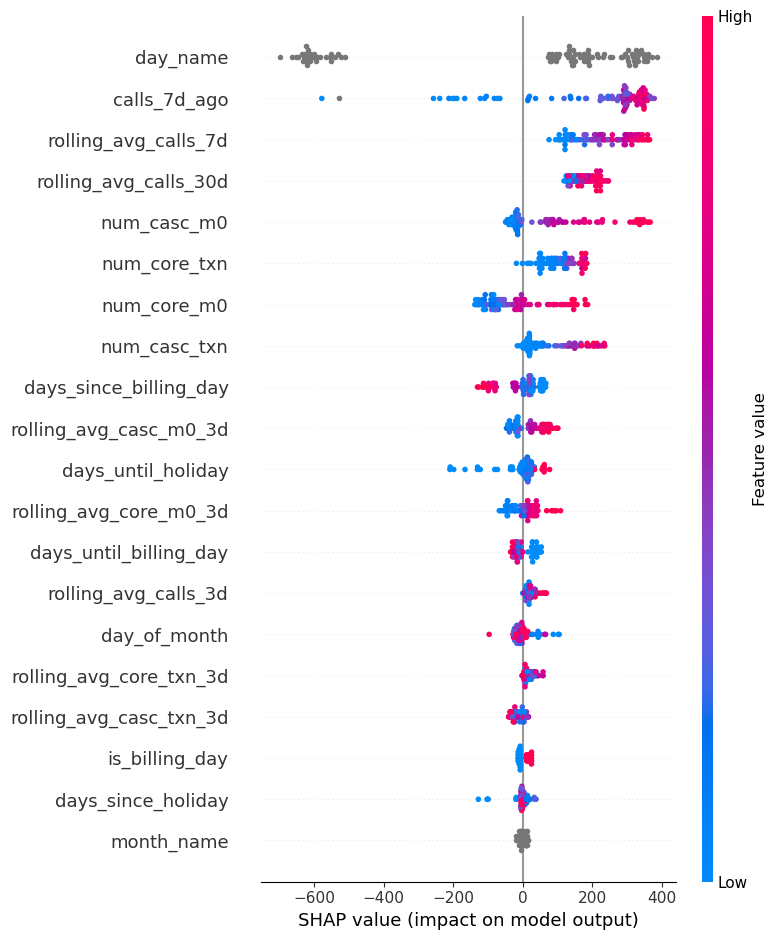

In [148]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP explainer using your trained CatBoost model
# TreeExplainer is highly optimized for CatBoost/XGBoost and runs instantly
explainer = shap.TreeExplainer(model)

# 2. Calculate the SHAP values for your test dataset
# We use X_test so we can see how the model makes decisions on *unseen* data
shap_values = explainer.shap_values(X_test)

# 3. Generate the Summary Plot
# This will open a graph showing every feature's impact on your predictions
shap.summary_plot(shap_values, X_test)